In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df = pd.read_csv('Perth_temp_data/temperatures.csv').dropna()\

,Product code,Bureau of Meteorology station number,Year,Month,Day,Maximum temperature (Degree C),Days of accumulation of maximum temperature,Quality
155,IDCJAC0010,9021,1944,6,4,23.4,1.0,Y
156,IDCJAC0010,9021,1944,6,5,20.3,1.0,Y
157,IDCJAC0010,9021,1944,6,6,18.7,1.0,Y
158,IDCJAC0010,9021,1944,6,7,21.3,1.0,Y
159,IDCJAC0010,9021,1944,6,8,21.6,1.0,Y
...,...,...,...,...,...,...,...,...
30061,IDCJAC0010,9021,2026,4,21,21.2,1.0,N
30062,IDCJAC0010,9021,2026,4,22,24.6,1.0,N
30063,IDCJAC0010,9021,2026,4,23,21.3,1.0,N
30064,IDCJAC0010,9021,2026,4,24,22.1,1.0,N


In [ ]:
df_summer = df[df['Month'].isin([1, 2, 12])]

7390

In [49]:
df_summer['SummerYear'] = df_summer['Year']
df_summer.loc[df_summer['Month'] == 12, 'SummerYear'] += 1
df_summer['Day'] = df_summer.groupby('SummerYear').cumcount() + 1
df_summer['Temp_smooth'] = (
    df_summer['Maximum temperature (Degree C)']
    .rolling(window=14, center=True)
    .mean()
)

C:\Users\joelw\AppData\Local\Temp\ipykernel_30676\2363023443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_summer['SummerYear'] = df_summer['Year']
C:\Users\joelw\AppData\Local\Temp\ipykernel_30676\2363023443.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_summer['Day'] = df_summer.groupby('SummerYear').cumcount() + 1
C:\Users\joelw\AppData\Local\Temp\ipykernel_30676\2363023443.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

In [75]:
import scipy.stats as stats
percentile_rank = []
current_avg = []
years_of_interest = [2022, 2023, 2024, 2025, 2026]
for i in range(len(years_of_interest)):
    summer_means = df_summer.groupby('SummerYear')['Temp_smooth'].mean()
    current_year = years_of_interest[i]
    current_avg.append(round(summer_means.loc[current_year], 2))
    percentile_rank.append(stats.percentileofscore(summer_means, current_avg[i]))
    print(f"Average temperature for the summer of ({current_year}): {current_avg[i]:.2f}°C")
    print(f"This summer is warmer than {percentile_rank[i]:.1f}% of all summers on record.")
print(f"Historical mean: {summer_means.mean():.2f}°C")
print(f"Historical max: {summer_means.max():.2f}°C")
print(f"Historical min: {summer_means.min():.2f}°C")

Average temperature for the summer of (2022): 33.94°C
This summer is warmer than 98.8% of all summers on record.
Average temperature for the summer of (2023): 32.39°C
This summer is warmer than 86.6% of all summers on record.
Average temperature for the summer of (2024): 34.19°C
This summer is warmer than 100.0% of all summers on record.
Average temperature for the summer of (2025): 33.70°C
This summer is warmer than 97.6% of all summers on record.
Average temperature for the summer of (2026): 33.39°C
This summer is warmer than 95.1% of all summers on record.
Historical mean: 31.08°C
Historical max: 34.19°C
Historical min: 28.55°C


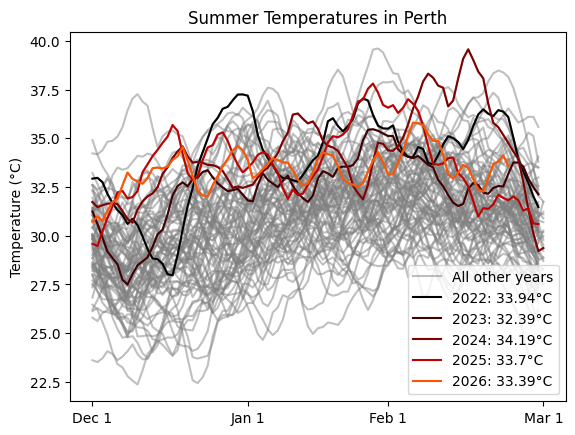

In [76]:
colors = plt.cm.gist_heat(np.linspace(0, 1, 7))

i = 0
for year in df_summer['SummerYear'].unique():

    # Plot all summers in grey
    subset = df_summer[df_summer['SummerYear'] == year]
    plt.plot(subset['Day'], subset['Temp_smooth'], color='grey', alpha=0.5, label='All other years' if year == 2021 else "")

    # Highlight recent summers (2022+)
    if year >= 2022:
        plt.plot(subset['Day'], subset['Temp_smooth'], color=colors[i], label=str(year)+": "+str(current_avg[i]) + "°C")
        i += 1

plt.xticks([1, 32, 60, 91], ['Dec 1', 'Jan 1', 'Feb 1', 'Mar 1'])
plt.ylabel('Temperature (°C)')
plt.title('Summer Temperatures in Perth')
plt.legend()
plt.show()


Average temperature this summer (2026): 33.39°C
Historical mean: 31.08°C
Historical max: 34.19°C
Historical min: 28.55°C
This summer is warmer than 96.3% of all summers on record.
